# Open Medic 2024 — Drug Spending Analysis
## France, 2024 (Full Year)

Data sources:  
- [Open Medic : base complète sur les dépenses de médicaments - 2014 à 2024 | L'Assurance Maladie](https://www.assurance-maladie.ameli.fr/etudes-et-donnees/open-medic-base-complete-depenses-medicaments)  
- [Open Medic : bases complémentaires sur les dépenses de médicaments - 2014 à 2024 | L'Assurance Maladie](https://www.assurance-maladie.ameli.fr/etudes-et-donnees/open-medic-depenses-beneficiaires-medicaments#text_191308)  
Codebook: [2024_descriptif-variables_open-medic.xls](https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fwww.assurance-maladie.ameli.fr%2Fsites%2Fdefault%2Ffiles%2F2024_descriptif-variables_open-medic.xls&wdOrigin=BROWSELINK)   
Coverage: Régime général, France entière, January–December 2024  
Tool: pandas · matplotlib · seaborn

---

### Research questions
- How is drug reimbursement distributed across therapeutic classes?
- Which molecules drive national spending, and at what cost per patient?
- How does spending vary by age, sex, and prescriber specialty?
- What is the balance between branded and generic drugs?
- What structural patterns emerge at the prescriber level?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paths
RAW_CSV    = 'OPEN_MEDIC_2024.CSV'
NB_ATC1    = 'NB_2024_atc1.CSV'
NB_AGE_SEX = 'NB_2024_atc1_age_sexe.CSV'
NB_FULL    = 'NB_2024_atc1_age_sexe_reg_spe.CSV'

In [2]:
# ── French number parsing ─────────────────────────────────────────
# Open Medic uses French locale: dots = thousands sep, commas = decimal
# e.g. '1.761,57' → 1761.57
# Applied at load time via .str.replace() chained directly on columns.

def parse_fr_col(series):
    return (series.str.replace('.', '', regex=False)
                  .str.replace(',', '.', regex=False)
                  .astype(float))

def parse_int_col(series):
    return (series.astype(str)
                  .str.replace('.', '', regex=False)
                  .str.replace(',', '', regex=False)
                  .astype(int))

# ── Plot style constants ──────────────────────────────────────────
CLASS_COLORS = {
    'L':'#C0392B','N':'#8E44AD','A':'#27AE60','B':'#E67E22',
    'C':'#2980B9','J':'#16A085','R':'#D35400','S':'#2C3E50',
    'H':'#7F8C8D','D':'#5D6D7E','M':'#95A5A6','G':'#1ABC9C',
    'V':'#ECF0F1','P':'#F39C12'
}

AGE_COLORS = {'0–19':'#3498DB', '20–59':'#E67E22', '60+':'#C0392B'}
SEX_COLORS = {'Male':'#2980B9', 'Female':'#E91E63'}
GEN_COLORS = {'Non-generic': '#2C3E50','Generic': '#1ABC9C',
              'Princeps': '#F1C40F', 'Unknown': '#BDC3C7'}

def horizontal_bar(ax, labels, values, colors, xlabel, title, suffix=''):
    bars = ax.barh(labels, values, color=colors, edgecolor='none', height=0.7)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}{suffix}', va='center', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    return bars

def clean_label(series, n=30):
    return series.str.title().apply(lambda x: x[:n] + '…' if len(x) > n else x)

In [3]:
# ── Label maps ────────────────────────────────────────────────────
AGE_MAP = {0: '0–19', 20: '20–59', 60: '60+', 99: 'Unknown'}
SEX_MAP = {1: 'Male', 2: 'Female', 9: 'Unknown'}

TOPGEN_MAP = {0: 'Non-generic', 1: 'Generic', 4: 'Princeps', 9: 'Unknown'}

ATC1_SHORT = {
    'A': 'Digestive/Metabolism',
    'B': 'Blood/Haematopoietic',
    'C': 'Cardiovascular',
    'D': 'Dermatology',
    'G': 'Genitourinary',
    'H': 'Systemic hormones',
    'J': 'Anti-infectives',
    'L': 'Antineoplastic/Immunomod.',
    'M': 'Musculoskeletal',
    'N': 'Nervous system',
    'P': 'Antiparasitic',
    'R': 'Respiratory',
    'S': 'Sensory organs',
    'V': 'Various'
}

PSP_MAP = {
    1:  'General practice (liberal)',
    2:  'Anaesthesiology (liberal)',
    3:  'Cardiology (liberal)',
    4:  'Surgery (liberal)',
    5:  'Dermatology (liberal)',
    6:  'Radiology (liberal)',
    7:  'Gynaecology (liberal)',
    8:  'Gastroenterology (liberal)',
    9:  'Internal medicine (liberal)',
    11: 'ENT (liberal)',
    12: 'Paediatrics (liberal)',
    13: 'Pulmonology (liberal)',
    14: 'Rheumatology (liberal)',
    15: 'Ophthalmology (liberal)',
    17: 'Psychiatry (liberal)',
    18: 'Stomatology (liberal)',
    19: 'Dental surgery',
    31: 'Rehab medicine (liberal)',
    32: 'Neurology (liberal)',
    35: 'Nephrology (liberal)',
    36: 'Dental surgery - ODF',
    37: 'Pathology (liberal)',
    38: 'Lab director (liberal)',
    42: 'Endocrinology (liberal)',
    90: 'Hospital (salaried)',
    98: 'Other outpatient (non-physician)',
    99: 'Unknown'
}

In [4]:
# ── Load raw CSV ──────────────────────────────────────────────────
df = pd.read_csv(RAW_CSV, sep=';', encoding='latin-1')
df['REM_f'] = parse_fr_col(df['REM'])
df['BSE_f'] = parse_fr_col(df['BSE'])

print(f"Rows          : {len(df):,}")
print(f"Total REM     : {df['REM_f'].sum()/1e9:.3f} B€")
print(f"Total BSE     : {df['BSE_f'].sum()/1e9:.3f} B€")
print(f"Total boxes   : {df['BOITES'].sum()/1e9:.3f} Bn")
print(f"Unique ATC5   : {df['ATC5'].nunique()}")

Rows          : 1,916,885
Total REM     : 26.032 B€
Total BSE     : 29.720 B€
Total boxes   : 2.368 Bn
Unique ATC5   : 1166


In [5]:
# ── Load NB_ complementary files ─────────────────────────────────
nb1 = pd.read_csv(NB_ATC1, sep=';', encoding='latin-1')
nb1['REM_f']    = parse_fr_col(nb1['REM'])
nb1['BSE_f']    = parse_fr_col(nb1['BSE'])
nb1['nbc_i']    = parse_int_col(nb1['nbc'])
nb1['boites_i'] = parse_int_col(nb1['BOITES'])
nb1['cpp']      = nb1['REM_f'] / nb1['nbc_i']

nb2 = pd.read_csv(NB_AGE_SEX, sep=';', encoding='latin-1')
nb2['REM_f']  = parse_fr_col(nb2['REM'])
nb2['nbc_i']  = parse_int_col(nb2['nbc'])
nb2['cpp']    = nb2['REM_f'] / nb2['nbc_i']
nb2['age_l']  = nb2['age'].map(AGE_MAP)
nb2['sex_l']  = nb2['sexe'].map(SEX_MAP)

nb3 = pd.read_csv(NB_FULL, sep=';', encoding='latin-1')
nb3['REM_f']  = parse_fr_col(nb3['REM'])
nb3['nbc_i']  = parse_int_col(nb3['nbc'])
nb3['psp_l']  = nb3['PSP_SPE'].map(PSP_MAP)

print(f"nb1 — ATC1 only                    : {len(nb1):>6} rows")
print(f"nb2 — ATC1 × age × sex             : {len(nb2):>6} rows")
print(f"nb3 — ATC1 × age × sex × reg × spe : {len(nb3):>6} rows")

nb1 — ATC1 only                    :     14 rows
nb2 — ATC1 × age × sex             :    167 rows
nb3 — ATC1 × age × sex × reg × spe :  21975 rows


In [6]:
# ── Section 1 — National Overview ────────────────────────────────
# ATC1 spend breakdown
atc1_df = (df.groupby(['ATC1', 'l_ATC1'])
             .agg(REM=('REM_f', 'sum'), BSE=('BSE_f', 'sum'), BOITES=('BOITES', 'sum'))
             .reset_index()
             .sort_values('REM', ascending=False))

atc1_df['short']   = atc1_df['ATC1'].map(ATC1_SHORT)
atc1_df['REM_B']   = atc1_df['REM'] / 1e9
atc1_df['pct']     = atc1_df['REM'] / atc1_df['REM'].sum() * 100
atc1_df['coverage']= atc1_df['REM'] / atc1_df['BSE'] * 100

total_rem    = df['REM_f'].sum()
total_bse    = df['BSE_f'].sum()
total_boites = df['BOITES'].sum()
coverage     = total_rem / total_bse * 100

print(f"Total REM      : {total_rem/1e9:.3f} B€")
print(f"Total BSE      : {total_bse/1e9:.3f} B€")
print(f"Coverage rate  : {coverage:.1f}%")
print(f"Total boxes    : {total_boites/1e9:.3f} Bn")
print(f"Unique ATC5    : {df['ATC5'].nunique()}")

Total REM      : 26.032 B€
Total BSE      : 29.720 B€
Coverage rate  : 87.6%
Total boxes    : 2.368 Bn
Unique ATC5    : 1166


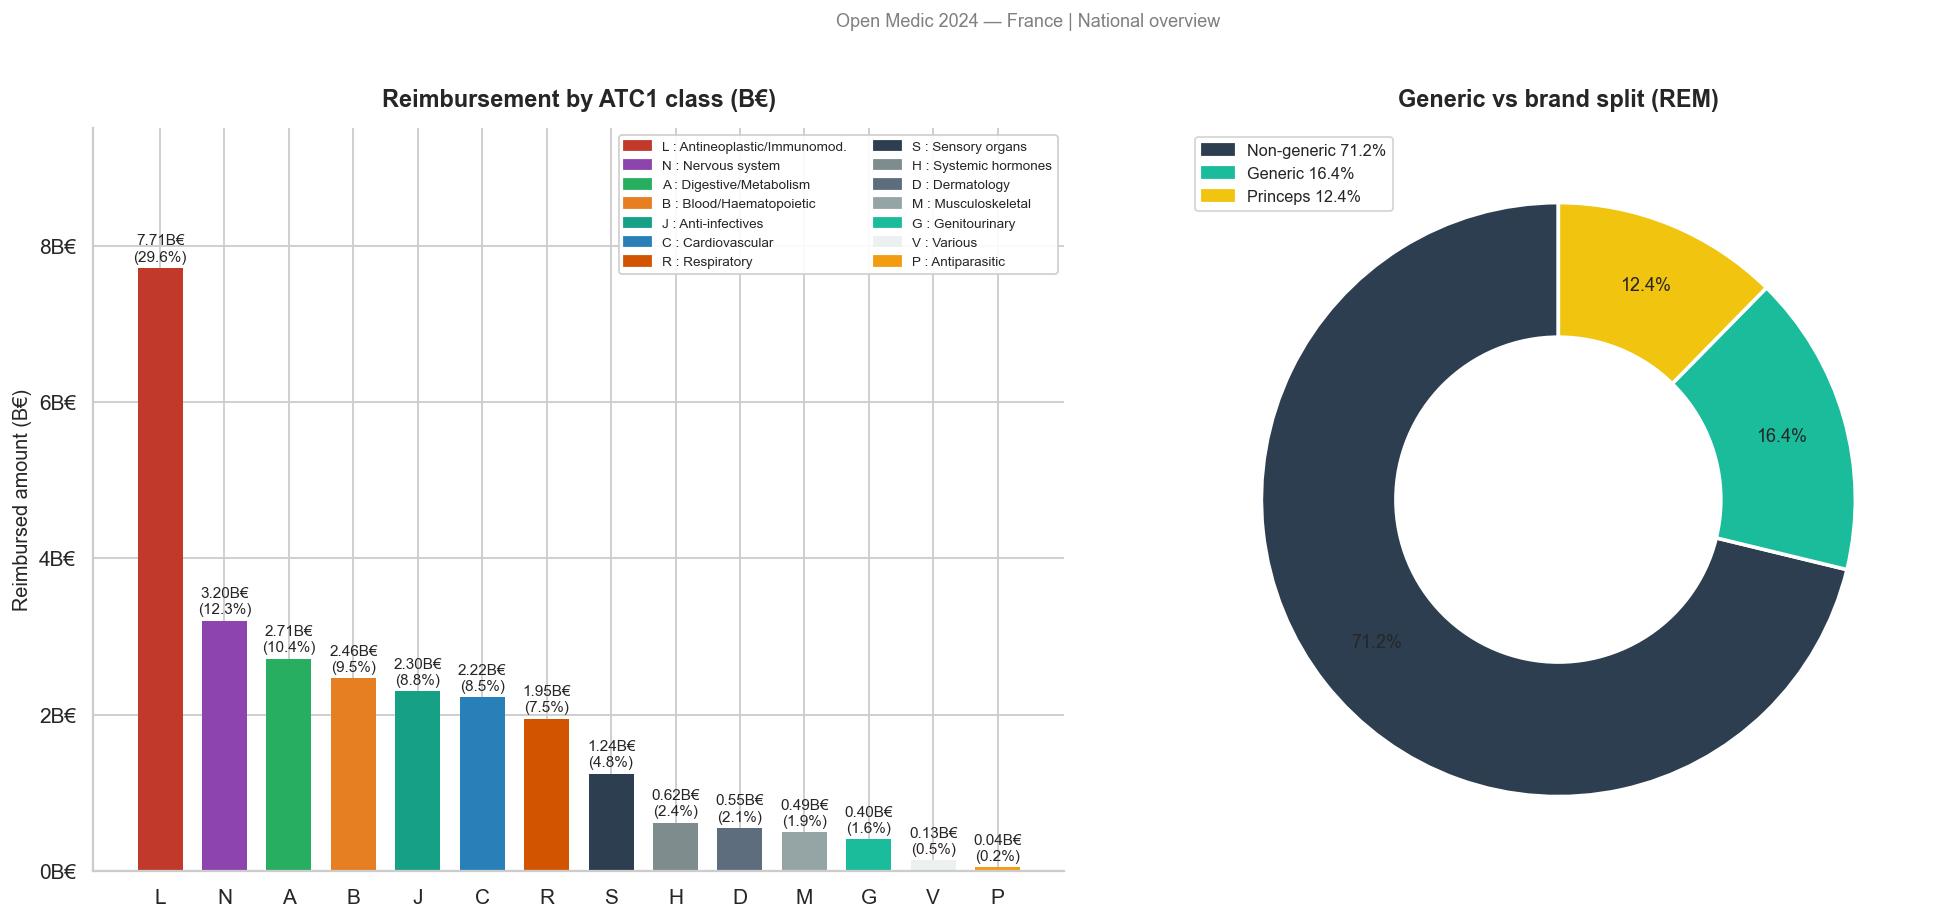

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: vertical bar — REM by ATC1 ─────────────────────────
ax = axes[0]
colors = [CLASS_COLORS[k] for k in atc1_df['ATC1']]
bars = ax.bar(atc1_df['ATC1'], atc1_df['REM_B'],
              color=colors, edgecolor='none', width=0.7)
for bar, row in zip(bars, atc1_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.REM_B:.2f}B€\n({row.pct:.1f}%)',
            ha='center', va='bottom', fontsize=8.5)
ax.set_ylabel('Reimbursed amount (B€)', fontsize=11)
ax.set_title('Reimbursement by ATC1 class (B€)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B€'))

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(color=CLASS_COLORS[k], label=f'{k} : {ATC1_SHORT[k]}')
                   for k in atc1_df['ATC1']]
ax.legend(handles=legend_elements, fontsize=7.5, ncol=2,
          loc='upper right', framealpha=0.9)

# ── Right: donut — generic vs brand ──────────────────────────
ax2 = axes[1]
gen_df = (df.groupby('TOP_GEN')['REM_f'].sum()
            .reset_index()
            .rename(columns={'REM_f': 'REM'}))
gen_df['label']  = gen_df['TOP_GEN'].map(TOPGEN_MAP)
gen_df['pct']    = gen_df['REM'] / gen_df['REM'].sum() * 100
gen_df = gen_df[gen_df['label'] != 'Unknown']
colors_g = [GEN_COLORS[l] for l in gen_df['label']]

wedges, texts, autotexts = ax2.pie(
    gen_df['REM'], labels=None,
    colors=colors_g, autopct='%1.1f%%',
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Generic vs brand split (REM)', fontsize=13, fontweight='bold', pad=12)
ax2.legend(handles=[Patch(color=GEN_COLORS[l], label=f'{l} {row.pct:.1f}%')
                    for l, row in zip(gen_df['label'], gen_df.itertuples())],
           fontsize=9, loc='upper left')

plt.suptitle('Open Medic 2024 — France | National overview', 
             fontsize=10, color='grey', y=1.01)
plt.tight_layout()
plt.show()

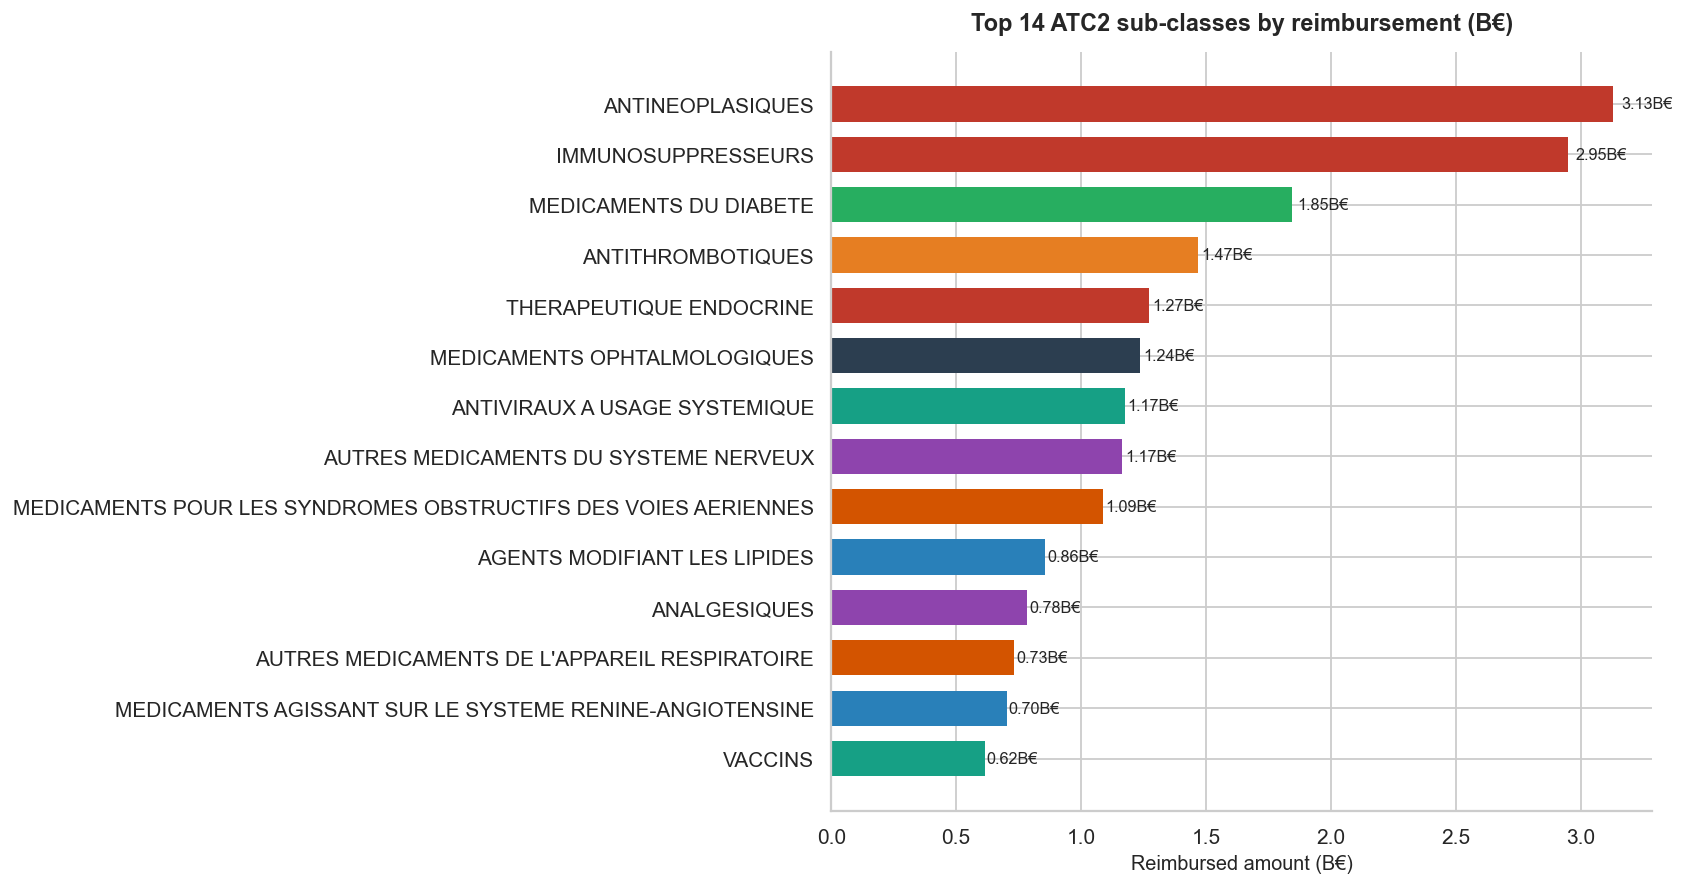

In [8]:
# ── ATC2 top 14 bar ───────────────────────────────────────────
atc2_df = (df.groupby(['ATC2', 'L_ATC2'])['REM_f'].sum()
             .reset_index()
             .sort_values('REM_f', ascending=False)
             .head(14))
atc2_df['REM_M'] = atc2_df['REM_f'] / 1e9
atc2_df['color'] = atc2_df['ATC2'].str[0].map(CLASS_COLORS)

fig, ax = plt.subplots(figsize=(13, 7))
horizontal_bar(ax,
               labels=atc2_df['L_ATC2'][::-1],
               values=atc2_df['REM_M'][::-1],
               colors=atc2_df['color'][::-1].tolist(),
               xlabel='Reimbursed amount (B€)',
               title='Top 14 ATC2 sub-classes by reimbursement (B€)',
               suffix='B€')
plt.tight_layout()
plt.show()

### Findings — National Overview

Total drug reimbursement in 2024: **26.03 B€** on a base of 29.72 B€ and a national coverage rate of **87.6%**. The remaining 12.4% is the patient co-pay (*ticket modérateur*).

**Class L (Antineoplastic/Immunomodulators)** dominates at **7.71 B€ (29.6%)**, which is nearly a third of the entire national drug bill. Every other class is less than half that. 

**Generic substitution has succeeded in volume but not in spend**: 71.2% of reimbursed spending goes to non-generic branded products, drugs where no cheaper alternative exists. This is not a policy failure but a structural ceiling: the most expensive drugs (biologics, targeted therapies) simply have no generics yet.

At ATC2 level, **L01 (Antineoplastics)** and **L04 (Immunosuppressants)** together account for **6.08 B€ (23.4% of total)**, almost a quarter of the national drug bill in two sub-classes alone.

In [9]:
# ── Section 3 — Molecule-level analysis (ATC5) ───────────────────
atc5_df = (df.groupby(['ATC5', 'L_ATC5', 'ATC1'])
             .agg(REM=('REM_f', 'sum'), BOITES=('BOITES', 'sum'))
             .reset_index())

atc5_df['L_ATC5']   = atc5_df['L_ATC5'].str.title()
atc5_df['REM_M']    = atc5_df['REM'] / 1e6
atc5_df['BOI_M']    = atc5_df['BOITES'] / 1e6
atc5_df['cost_box'] = atc5_df['REM'] / atc5_df['BOITES']
atc5_df['color']    = atc5_df['ATC1'].map(CLASS_COLORS)

top25_rem = atc5_df.sort_values('REM', ascending=False).head(25)
top25_vol = atc5_df.sort_values('BOITES', ascending=False).head(25)

print(f"Unique molecules : {len(atc5_df)}")
print(f"\nTop 5 by spend:")
print(top25_rem[['ATC5','L_ATC5','REM_M','BOI_M','cost_box']].head().to_string(index=False))
print(f"\nTop 5 by volume:")
print(top25_vol[['ATC5','L_ATC5','REM_M','BOI_M','cost_box']].head().to_string(index=False))

Unique molecules : 1166

Top 5 by spend:
   ATC5                               L_ATC5  REM_M  BOI_M  cost_box
N07XX08                            Tafamidis 860.34   0.12  7,174.90
B01AF02                             Apixaban 805.64  14.58     55.24
L04AB04                           Adalimumab 501.89   1.10    455.34
S01LA05                          Aflibercept 499.81   0.78    641.41
R07AX32 Ivacaftor + Tezacaftor + Elexacaftor 461.91   0.05  9,383.70

Top 5 by volume:
   ATC5                  L_ATC5  REM_M  BOI_M  cost_box
N02BE01             Paracetamol 377.45 437.10      0.86
A11CC05          Colecalciferol  78.59  71.42      1.10
J01CA04            Amoxicilline  71.76  47.22      1.52
B01AC06 Acetylsalicylique Acide  64.16  38.07      1.69
A02BC05            Esomeprazole  96.05  30.93      3.11


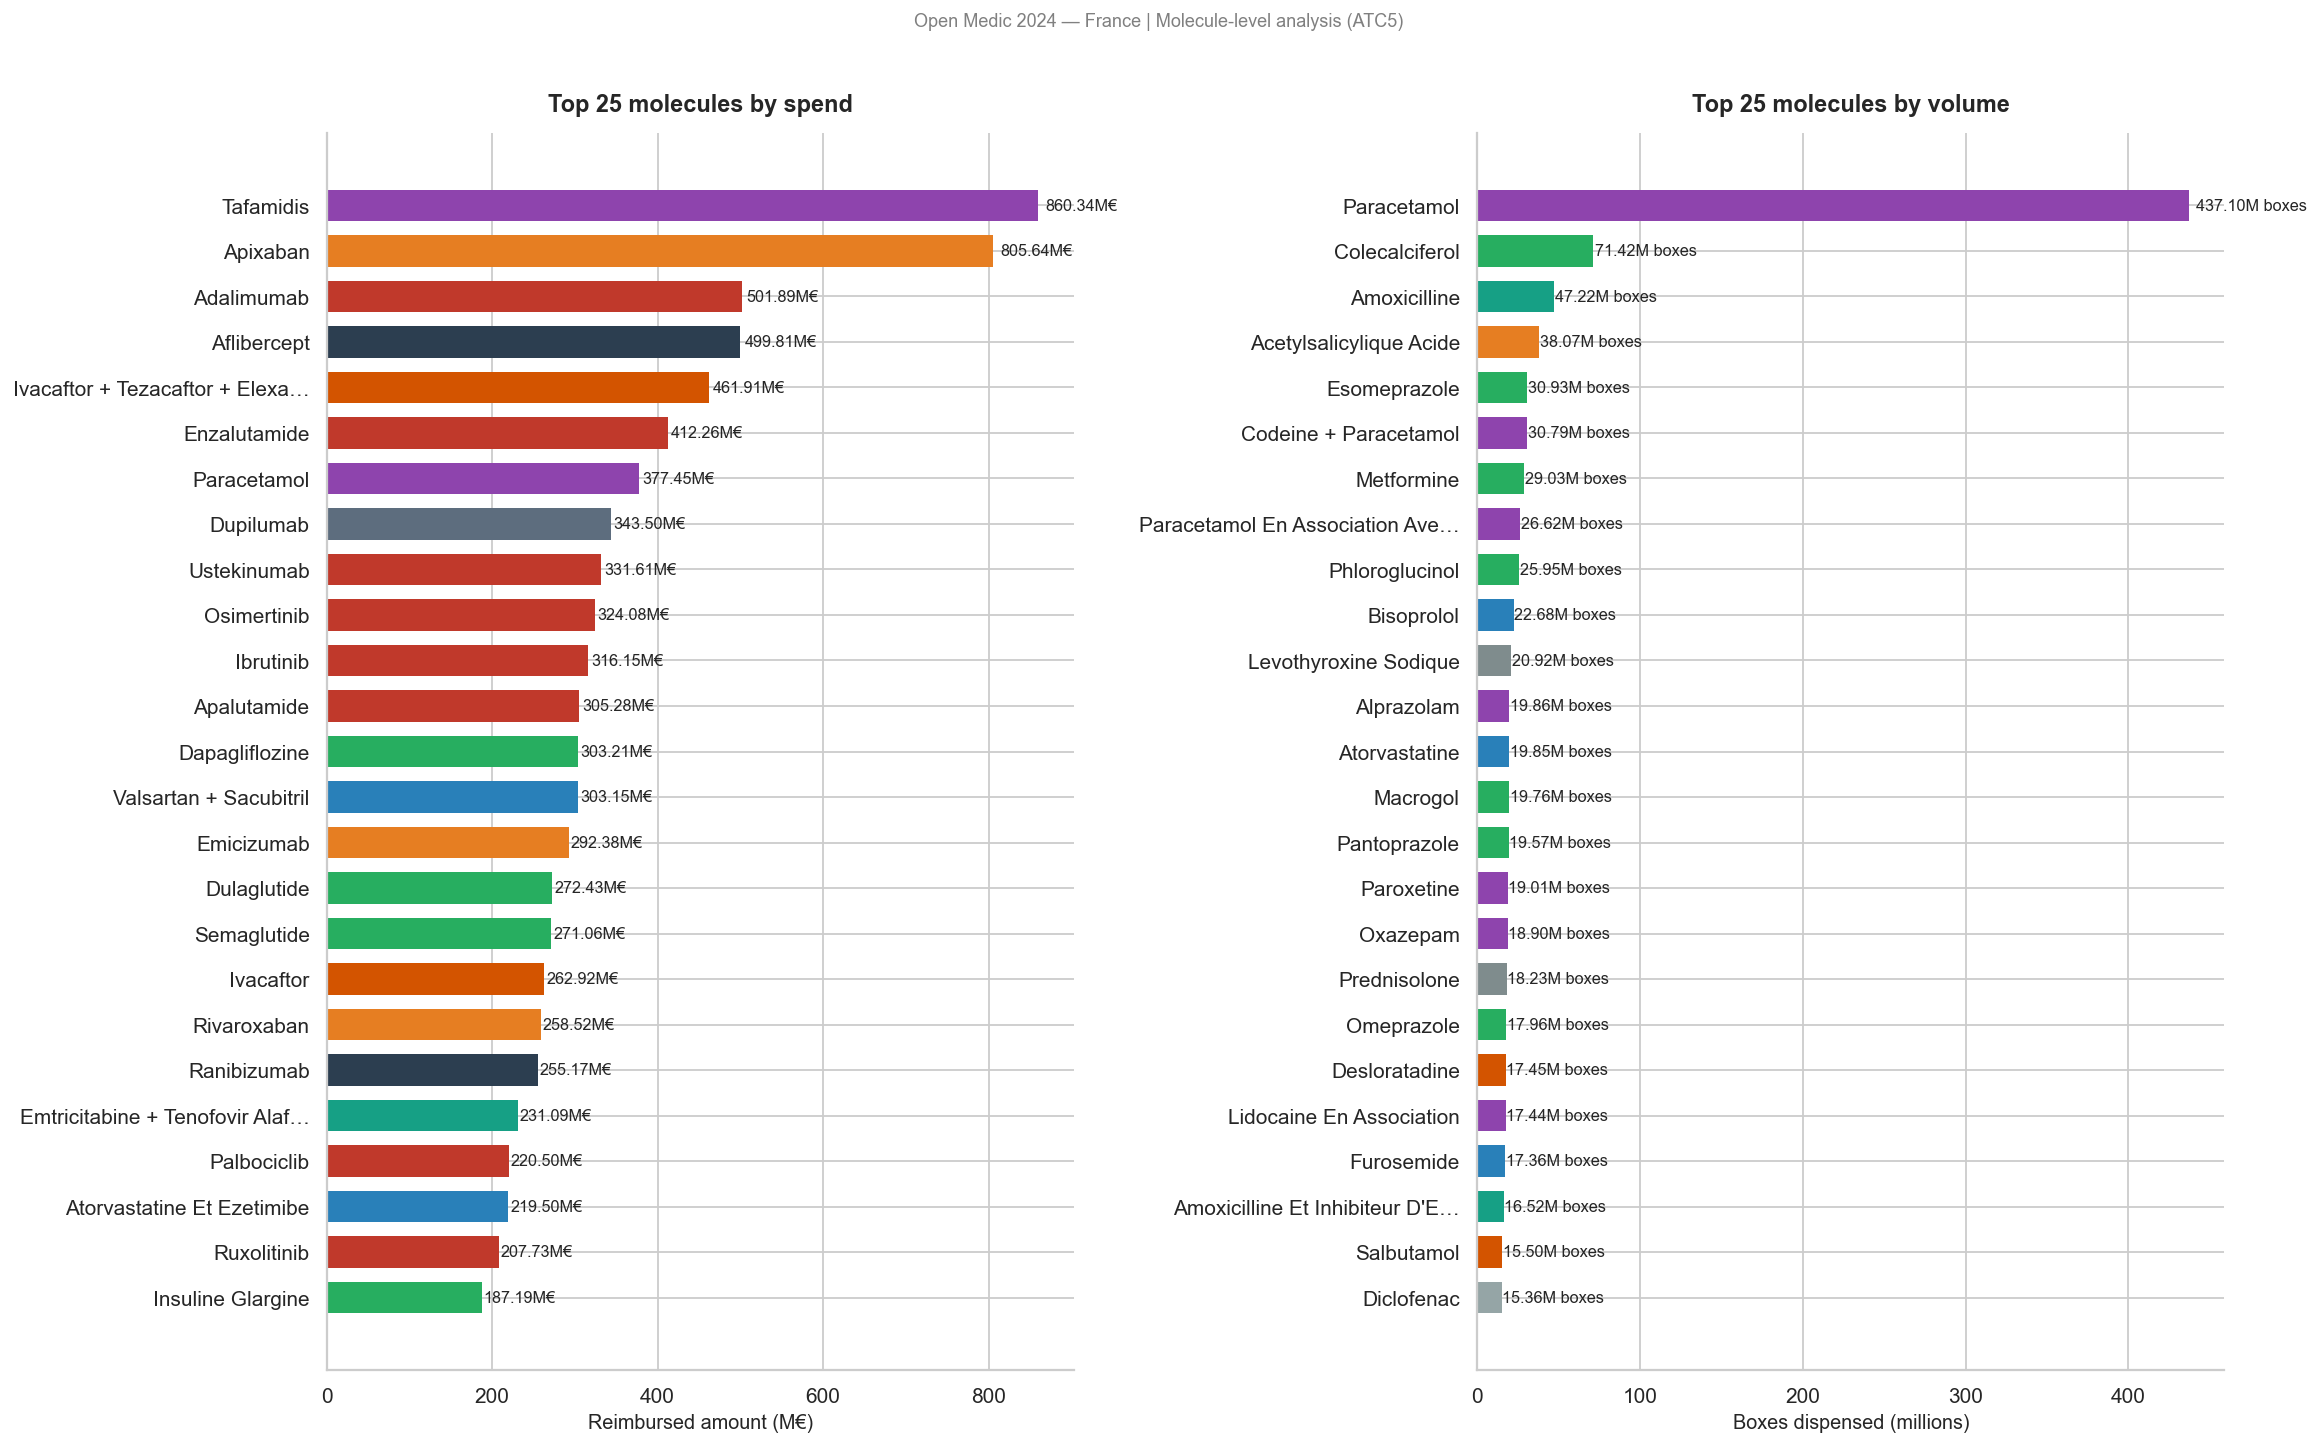

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 11))

# ── Left: top 25 by spend ─────────────────────────────────────
ax = axes[0]
horizontal_bar(
    ax,
    labels=clean_label(top25_rem['L_ATC5'])[::-1].tolist(),
    values=top25_rem['REM_M'][::-1].values,
    colors=top25_rem['color'][::-1].tolist(),
    xlabel='Reimbursed amount (M€)',
    title='Top 25 molecules by spend',
    suffix='M€'
)

# ── Right: top 25 by volume ───────────────────────────────────
ax2 = axes[1]
horizontal_bar(
    ax2,
    labels=clean_label(top25_vol['L_ATC5'])[::-1].tolist(),
    values=top25_vol['BOI_M'][::-1].values,
    colors=top25_vol['color'][::-1].tolist(),
    xlabel='Boxes dispensed (millions)',
    title='Top 25 molecules by volume',
    suffix='M boxes'
)

plt.suptitle('Open Medic 2024 — France | Molecule-level analysis (ATC5)',
             fontsize=10, color='grey', y=1.01)
plt.tight_layout()
plt.show()

### Findings — Molecule level

**Tafamidis (N07XX08)** is the single most expensive molecule at **860 M€** across only 0.12 million boxes with **€7,175 reimbursed per box**. It treats transthyretin amyloidosis cardiomyopathy, a rare cardiac disease affecting a small patient population. It alone represents 3.3% of the entire national drug bill.

**Apixaban (B01AF02)** ranks second at **806 M€** across 14.6 million boxes (€55 reimbursed per box in average).

**Paracetamol (N02BE01)** appears in both charts: 7th by spend (377 M€) and 1st by volume with **437 million boxes**. It is the most dispensed molecule in France at €0.86 reimbursed per box on average.

Among the top 25 by volume, **Alprazolam (19.9M boxes), Oxazepam (18.9M boxes)** **Paroxetine (19.0M boxes)** stand out: anxiolytics and antidepressants consumed at mass scale, consistent with France's position as one of the highest consumers of psychoactive drugs in Europe (Gentile et al., 2020; Martella et al., 2024; Alabaku et al., 2023).


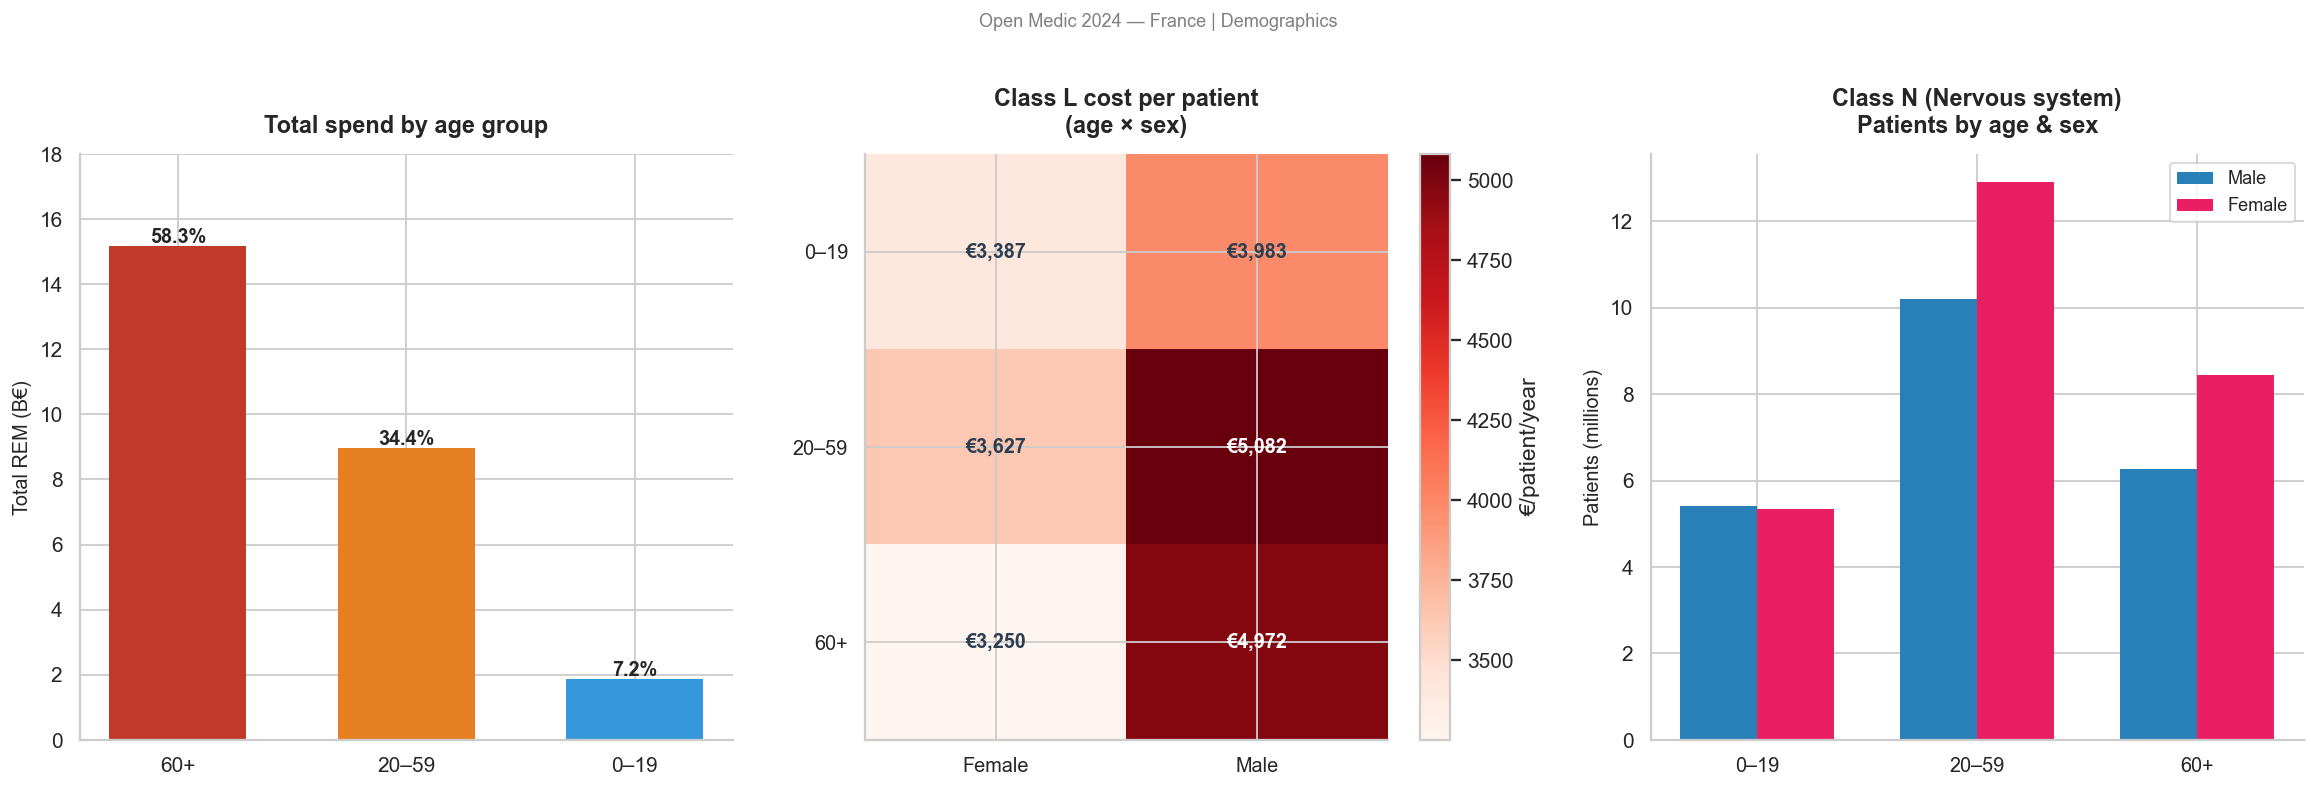

In [11]:
# ── Section 4 — Demographics ──────────────────────────────────────
age_df = (df.groupby('age')['REM_f'].sum()
            .reset_index()
            .rename(columns={'REM_f': 'REM'}))
age_df['age_l'] = age_df['age'].map(AGE_MAP)
age_df['pct']   = age_df['REM'] / age_df['REM'].sum() * 100
age_df['REM_B'] = age_df['REM'] / 1e9
age_df = age_df[age_df['age_l'] != 'Unknown'].sort_values('REM_B', ascending=False)

l_df    = nb2[(nb2['ATC1'] == 'L') & (nb2['sex_l'] != 'Unknown')].copy()
l_pivot = l_df.pivot_table(values='cpp', index='age_l',
                            columns='sex_l', aggfunc='sum')
l_pivot = l_pivot.reindex(['0–19', '20–59', '60+'])

n_df      = nb2[(nb2['ATC1'] == 'N') & (nb2['sex_l'] != 'Unknown')].copy()
age_order = ['0–19', '20–59', '60+']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: age share of total spend ───────────────────────────────
ax = axes[0]
bars = ax.bar(age_df['age_l'], age_df['REM_B'],
              color=[AGE_COLORS[a] for a in age_df['age_l']],
              edgecolor='none', width=0.6)
for bar, row in zip(bars, age_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{row.pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Total REM (B€)', fontsize=11)
ax.set_title('Total spend by age group', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 18)

# ── Centre: class L cost per patient heatmap ─────────────────────
ax2 = axes[1]
im = ax2.imshow(l_pivot.values, cmap='Reds', aspect='auto')
ax2.set_xticks(range(len(l_pivot.columns)))
ax2.set_xticklabels(l_pivot.columns, fontsize=11)
ax2.set_yticks(range(len(l_pivot.index)))
ax2.set_yticklabels(l_pivot.index, fontsize=11)
for i in range(len(l_pivot.index)):
    for j in range(len(l_pivot.columns)):
        val = l_pivot.values[i, j]
        ax2.text(j, i, f'€{val:,.0f}',
                 ha='center', va='center', fontsize=11,
                 color='white' if val > 4000 else '#2C3E50',
                 fontweight='bold')
ax2.set_title('Class L cost per patient\n(age × sex)',
              fontsize=13, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax2, label='€/patient/year')

# ── Right: class N patients by age × sex ─────────────────────────
ax3 = axes[2]
width = 0.35
x     = np.arange(len(age_order))
male   = [n_df[(n_df['age_l'] == a) & (n_df['sex_l'] == 'Male')]['nbc_i'].sum() / 1e6
          for a in age_order]
female = [n_df[(n_df['age_l'] == a) & (n_df['sex_l'] == 'Female')]['nbc_i'].sum() / 1e6
          for a in age_order]
ax3.bar(x - width / 2, male,   width, label='Male',
        color=SEX_COLORS['Male'],   edgecolor='none')
ax3.bar(x + width / 2, female, width, label='Female',
        color=SEX_COLORS['Female'], edgecolor='none')
ax3.set_xticks(x)
ax3.set_xticklabels(age_order, fontsize=11)
ax3.set_ylabel('Patients (millions)', fontsize=11)
ax3.set_title('Class N (Nervous system)\nPatients by age & sex',
              fontsize=13, fontweight='bold', pad=12)
ax3.legend(fontsize=10)

plt.suptitle('Open Medic 2024 — France | Demographics',
             fontsize=10, color='grey', y=1.01)
plt.tight_layout()
plt.show()

### Findings — Demographics

Within class L, male patients aged 20–59 carry the highest cost per patient at
**€5,082/year**, surpassing 60+ males (€4,972) and being substantially above females in
the same band (€3,627). This could be explained by differences in cancer type
and treatment intensity across sex and age groups, though diagnosis-level data
would be required to confirm this  hypothesis.

**Female patients substantially outnumber male patients in class N** across all
adult age groups, most notably in the 20–59 cohort (12.9M vs 10.2M). One plausible
interpretation is that women carry a higher burden of anxiety, depression, and stress, a pattern well documented in the literature. 

This is reflected in psychometric data showing females scoring significantly higher
than males on all three DASS-42 subscales: depression (20.72 vs 20.07), anxiety
(16.32 vs 13.11), and stress (21.45 vs 18.41) across N=33,562 respondents (F>56,
p<0.0001).

-[DASS-42.ipynb](https://github.com/Nassour42/psych-data-training/blob/main/DASS-42.ipynb), cell 33: Gender × DASS-42 Scores.

## Conclusions

This analysis covers **1,916,885 reimbursement rows** across the full year 2024,
representing **26.03 B€ in total drug reimbursements** (87.6% coverage rate on a
29.72 B€ reimbursement base) and **2.37 billion boxes** dispensed across 1,166
distinct molecules.

### Key findings

Class L (Antineoplastic & Immunomodulators) represents 29.6% of total drug
spending at 7.71 B€ despite serving the smallest patient population of any
major class. At molecule level, Tafamidis alone (860 M€, €7,175 reimbursed per
box on average) accounts for 3.3% of the national drug bill.

Generic substitution has succeeded in volume but not in spending: They account
for 44.5% of boxes dispensed but only 16.4% of reimbursed expenditure. The
71.2% going to non-generic branded products largely reflects drug classes where
no biosimilar or generic exists yet.

Within class L, male patients aged 20–59 carry the highest cost per patient
(€5,082/year), a pattern that likely reflects differences in cancer type and
treatment intensity across sex and age groups. In class N, female patients
substantially outnumber males across all adult age groups, which is consistent with a
higher burden of anxiety, depression and stress in women, both in the literature
and in independent psychometric data (see
[DASS-42.ipynb](https://github.com/Nassour42/psych-data-training)).

Among the top 25 molecules by volume, Alprazolam, Oxazepam and Paroxetine stand
out, reflecting France's position as 2nd highest benzodiazepine consumer
in Europe (Gentile et al., 2020; Martella et al., 2024; Alabaku et al., 2023).

### Limitations

Open Medic is published as an annual aggregate. Monthly trends at molecule level
cannot be derived from this dataset alone.

Prescriber codes 99 (*inconnu*) and 90 (*salariés*) group heterogeneous prescriber
types that cannot be disaggregated here.

No diagnosis codes. Spending cannot be linked to clinical indications without
cross-referencing SNDS consumption data (DCIR), not publicly accessible.

Outpatient dispensings only. Hospital-dispensed drugs (rétrocession, liste en sus)
are excluded. Class L spending is substantially underestimated relative to true
total oncology drug costs.

### References

Gentile, G., Lapeyre-Mestre, M., & Micallef, J. (2020). Combatting the misuse of
benzodiazepines and related Z drugs in French general practice: A clinical review.
*BJGP Open*, *4*(1), bjgpopen20X101014. https://doi.org/10.3399/bjgpopen20X101014

Martella, M., Minutiello, E., & Gianino, M. M. (2024). Patterns of antidepressant
and anxiolytic use and spending in 14 European countries (2012–2021): A comprehensive
time series analysis. *Health Services Insights*, *17*, 11786329241282526.
https://doi.org/10.1177/11786329241282526

Alabaku, O., Yang, A., Tharmarajah, S., Suda, K., Vigod, S., & Tadrous, M. (2023).
Global trends in antidepressant, atypical antipsychotic, and benzodiazepine use:
A cross-sectional analysis of 64 countries. *PLOS ONE*, *18*(4), e0284389.
https://doi.org/10.1371/journal.pone.0284389